## BIRD

### Train

In [1]:
import json
import pandas as pd

In [2]:
train_data = json.load(open("../benchmarks/BIRD/train/train_tables.json", 'r'))
train_queries = json.load(open("../benchmarks/BIRD/train/train.json", 'r'))

In [3]:
total_tables = [len(train_data[i]['table_names']) for i in range(len(train_data))]
total_cols = [len(train_data[i]['column_names']) - 1 for i in range(len(train_data))]

In [4]:
dsname = 'BIRD/train'
db_stat = pd.DataFrame({
    'dataset': [dsname],
    'total_queries': [len(train_queries)],
    'mean_query_words': [round(sum(train_queries[i]['SQL'].replace('\n', ' ').count(' ') + 1 
                                   for i in range(len(train_queries))) / len(train_queries), 3)],
    'total_dbs': [len(train_data)],
    'total_tables': [sum(total_tables)],
    'total_columns': [sum(total_cols)],
    'mean_db_tb': [round(sum(total_tables) / len(total_tables), 3)],
    'mean_tb_cl': [round(sum(total_cols) / sum(total_tables), 3)],
    'mean_db_cl': [round(sum(total_cols) / len(total_cols), 3)]
})

print(db_stat.loc[db_stat['dataset'] == dsname, 'total_queries'].values[0], 'примеров SELECT запросов')
print(db_stat.loc[db_stat['dataset'] == dsname, 'total_dbs'].values[0], 'баз данных SQLite из разных областей')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_query_words'].values[0], 'слов на запрос')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_tables'].values[0], 'таблиц во всех базах данных')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_columns'].values[0], 'столбцов во всех таблицах всех базах данных')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_db_tb'].values[0], 'Таблиц на базу данных')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_tb_cl'].values[0], 'столбцов на таблицу')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_db_cl'].values[0], 'столбцов на базу данных')

9428 примеров SELECT запросов
69 баз данных SQLite из разных областей
В среднем 25.825 слов на запрос
Всего 522 таблиц во всех базах данных
Всего 3539 столбцов во всех таблицах всех базах данных
В среднем 7.565 Таблиц на базу данных
В среднем 6.78 столбцов на таблицу
В среднем 51.29 столбцов на базу данных


In [5]:
list(train_data[0].keys())

['db_id',
 'table_names_original',
 'table_names',
 'column_names_original',
 'column_names',
 'column_types',
 'primary_keys',
 'foreign_keys']

In [6]:
for i in range(len(train_data)):
    for j in range(len(train_data[i]['table_names_original'])):
        if train_data[i]['table_names_original'][j] != train_data[i]['table_names'][j]:
            print(train_data[i]['db_id'], ':', train_data[i]['table_names_original'][j], '|', train_data[i]['table_names'][j])


craftbeer : breweries | Breweries
craftbeer : beers | Beers
app_store : playstore | googleplaystore
app_store : user_reviews | googleplaystore_user_reviews
mondial_geo : mergesWith | mergeswith
mondial_geo : mountainOnIsland | mountainonisland
student_loan : filed_for_bankrupcy | filed_for_bankruptcy
world_development_indicators : Footnotes | FootNotes
coinmarketcap : coins | Coins
coinmarketcap : historical | Historical
shooting : incidents | Incidents


In [7]:
for i in range(len(train_data)):
    for j in range(len(train_data[i]['column_names_original'])):
        if train_data[i]['column_names_original'][j][1] != train_data[i]['column_names'][j][1]:
            print(train_data[i]['db_id'], ':', train_data[i]['column_names_original'][j][1], '|', train_data[i]['column_names'][j][1])


european_football_1 : Div | Division
european_football_1 : FTHG | Final-time Home-team Goals
european_football_1 : FTAG | Final-time Away-team Goals
european_football_1 : FTR | Final-time Results
sales_in_weather : store_nbr | store number
sales_in_weather : item_nbr | item number
sales_in_weather : station_nbr | station number
sales_in_weather : tmax | temperature max
sales_in_weather : tmin | temperature min
sales_in_weather : tavg | temperature average
sales_in_weather : depart | departure from normal
sales_in_weather : dewpoint | dew point
sales_in_weather : wetbulb | wet bulb
sales_in_weather : codesum | code summarization
sales_in_weather : stnpressure | station pressure
sales_in_weather : sealevel | sea level
sales_in_weather : resultspeed | resultant speed
sales_in_weather : resultdir | resultant direction
sales_in_weather : avgspeed | average speed
sales_in_weather : store_nbr | store number
sales_in_weather : station_nbr | station number
craftbeer : brewery_id | brewery id
cr

In [8]:
list(train_queries[0].keys())

['db_id', 'question', 'evidence', 'SQL']

In [9]:
syntax_elements = ['SELECT', ' WHERE', ' JOIN', ' LIMIT', ' ORDER BY', 'DESC', 'GROUP BY', 'BETWEEN', 'HAVING', 'WITH']
syntax_stat = pd.DataFrame({
    'dataset': [dsname for _ in range(len(syntax_elements))], 
    'syntax': list(map(str.strip, syntax_elements)),
    'freq': [sum(train_queries[i]['SQL'].count(elem) for i in range(len(train_queries))) 
             for elem in syntax_elements]
})

syntax_stat.loc[syntax_stat['dataset'] == dsname, syntax_stat.columns[syntax_stat.columns != 'dataset']]

,syntax,freq
0,SELECT,10284
1,WHERE,8550
2,JOIN,9593
3,LIMIT,1829
4,ORDER BY,1750
5,DESC,1642
6,GROUP BY,1026
7,BETWEEN,313
8,HAVING,139
9,WITH,1


### Dev

In [10]:
dev_data = json.load(open("../benchmarks/BIRD/dev/dev_20240627/dev_tables.json", 'r'))
dev_queries = json.load(open("../benchmarks/BIRD/dev/dev_20240627/dev.json", 'r'))

In [11]:
total_tables = [len(dev_data[i]['table_names']) for i in range(len(dev_data))]
total_cols = [len(dev_data[i]['column_names']) - 1 for i in range(len(dev_data))]

In [12]:
dsname = 'BIRD/dev'
db_stat = pd.concat([
    db_stat, 
    pd.DataFrame({
        'dataset': [dsname],
        'total_queries': [len(dev_queries)],
        'mean_query_words': [round(sum(dev_queries[i]['SQL'].replace('\n', ' ').count(' ') + 1 
                                       for i in range(len(dev_queries))) / len(dev_queries), 3)],
        'total_dbs': [len(dev_data)],
        'total_tables': [sum(total_tables)],
        'total_columns': [sum(total_cols)],
        'mean_db_tb': [round(sum(total_tables) / len(total_tables), 3)],
        'mean_tb_cl': [round(sum(total_cols) / sum(total_tables), 3)],
        'mean_db_cl': [round(sum(total_cols) / len(total_cols), 3)]
})], ignore_index=True)

print(db_stat.loc[db_stat['dataset'] == dsname, 'total_queries'].values[0], 'примеров SELECT запросов')
print(db_stat.loc[db_stat['dataset'] == dsname, 'total_dbs'].values[0], 'баз данных SQLite из разных областей')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_query_words'].values[0], 'слов на запрос')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_tables'].values[0], 'таблиц во всех базах данных')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_columns'].values[0], 'столбцов во всех таблицах всех базах данных')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_db_tb'].values[0], 'Таблиц на базу данных')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_tb_cl'].values[0], 'столбцов на таблицу')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_db_cl'].values[0], 'столбцов на базу данных')

1534 примеров SELECT запросов
11 баз данных SQLite из разных областей
В среднем 25.401 слов на запрос
Всего 75 таблиц во всех базах данных
Всего 798 столбцов во всех таблицах всех базах данных
В среднем 6.818 Таблиц на базу данных
В среднем 10.64 столбцов на таблицу
В среднем 72.545 столбцов на базу данных


In [13]:
list(dev_data[0].keys())

['db_id',
 'table_names_original',
 'table_names',
 'column_names_original',
 'column_names',
 'column_types',
 'primary_keys',
 'foreign_keys']

In [14]:
for i in range(len(dev_data)):
    for j in range(len(dev_data[i]['table_names_original'])):
        if dev_data[i]['table_names_original'][j] != dev_data[i]['table_names'][j]:
            print(dev_data[i]['db_id'], ':', dev_data[i]['table_names_original'][j], '|', dev_data[i]['table_names'][j])


debit_card_specializing : gasstations | gas stations
debit_card_specializing : transactions_1k | transactions
debit_card_specializing : yearmonth | year and month
financial : disp | disposition
financial : trans | transaction
formula_1 : constructorResults | constructor results
formula_1 : constructorStandings | constructor standings
formula_1 : driverStandings | driver standings
formula_1 : lapTimes | lap times
formula_1 : pitStops | pit stops
california_schools : frpm | free and reduced-price meals
california_schools : satscores | sat scores
card_games : foreign_data | foreign data
card_games : set_translations | set translations
card_games : rulings | ruling
european_football_2 : Player_Attributes | Player Attributes
european_football_2 : Team_Attributes | Team Attributes
student_club : event | Event
student_club : major | Major
student_club : zip_code | Zip Code
student_club : attendance | Attendance
student_club : budget | Budget
student_club : expense | Expense
student_club : inc

In [15]:
for i in range(len(dev_data)):
    for j in range(len(dev_data[i]['column_names_original'])):
        if dev_data[i]['column_names_original'][j][1] != dev_data[i]['column_names'][j][1]:
            print(dev_data[i]['db_id'], ':', dev_data[i]['column_names_original'][j][1], '|', dev_data[i]['column_names'][j][1])


debit_card_specializing : Segment | client segment
debit_card_specializing : GasStationID | Gas Station ID
debit_card_specializing : ChainID | Chain ID
debit_card_specializing : Segment | chain segment
debit_card_specializing : ProductID | Product ID
debit_card_specializing : TransactionID | Transaction ID
debit_card_specializing : CustomerID | Customer ID
debit_card_specializing : CardID | Card ID
debit_card_specializing : GasStationID | Gas Station ID
debit_card_specializing : ProductID | Product ID
debit_card_specializing : CustomerID | Customer ID
financial : account_id | account id
financial : district_id | location of branch
financial : card_id | credit card id
financial : disp_id | disposition id
financial : district_id | location of branch
financial : disp_id | disposition id
financial : district_id | location of branch
financial : A2 | district_name
financial : A3 | region
financial : A4 | number of inhabitants
financial : A5 | no. of municipalities with inhabitants < 499
fina

In [16]:
list(dev_queries[0].keys())

['question_id', 'db_id', 'question', 'evidence', 'SQL', 'difficulty']

In [17]:
syntax_elements = ['SELECT', ' WHERE', ' JOIN', ' LIMIT', ' ORDER BY', 'DESC', 'GROUP BY', 'BETWEEN', 'HAVING', 'WITH']
syntax_stat = pd.concat([
    syntax_stat, 
    pd.DataFrame({
        'dataset': [dsname for _ in range(len(syntax_elements))], 
        'syntax': list(map(str.strip, syntax_elements)),
        'freq': [sum(dev_queries[i]['SQL'].count(elem) for i in range(len(dev_queries))) 
                for elem in syntax_elements]
})], ignore_index=True)

syntax_stat.loc[syntax_stat['dataset'] == dsname, syntax_stat.columns[syntax_stat.columns != 'dataset']]

,syntax,freq
10,SELECT,1686
11,WHERE,1450
12,JOIN,1428
13,LIMIT,297
14,ORDER BY,305
15,DESC,216
16,GROUP BY,122
17,BETWEEN,77
18,HAVING,21
19,WITH,9


In [18]:
set(dev_queries[i]['difficulty'] for i in range(len(dev_queries)))

{'challenging', 'moderate', 'simple'}

In [19]:
for diff in ['simple', 'moderate', 'challenging']:
    print(diff, sum(1 for j in range(len(dev_queries)) 
                    if dev_queries[j]['difficulty'] == diff))


simple 925
moderate 464
challenging 145


In [20]:
for diff in ['simple', 'moderate', 'challenging']:
    print(diff, 
          round(sum(dev_queries[i]['SQL'].replace('\n', ' ').count(' ') + 1 
                    for i in range(len(dev_queries)) 
                    if dev_queries[i]['difficulty'] == diff) 
          / sum(1 for j in range(len(dev_queries)) if dev_queries[j]['difficulty'] == diff), 3))


simple 20.386
moderate 30.3
challenging 41.717


## Spider

In [21]:
import os

### Spider 2.0-Lite

In [22]:
lite_queries = pd.read_json('../benchmarks/Spider2/spider2-lite/spider2-lite.jsonl', lines=True)
lite_queries

,instance_id,db,question,external_knowledge,temporal
0,bq011,ga4,How many distinct pseudo users had positive en...,ga4_obfuscated_sample_ecommerce.events.md,NaN
1,bq010,ga360,Find the top-selling product among customers w...,google_analytics_sample.ga_sessions.md,NaN
2,bq009,ga360,Which traffic source has the highest total tra...,google_analytics_sample.ga_sessions.md,NaN
3,bq001,ga360,For each visitor who made at least one transac...,google_analytics_sample.ga_sessions.md,NaN
4,bq002,ga360,"During the first half of 2017, focusing on hi...",google_analytics_sample.ga_sessions.md,NaN
...,...,...,...,...,...
542,sf009,NETHERLANDS_OPEN_MAP_DATA,A real estate company needs a detailed side-by...,None,NaN
543,sf013,NETHERLANDS_OPEN_MAP_DATA,Compare the total road lengths in Amsterdam an...,None,NaN
544,sf041,YES_ENERGY__SAMPLE_DATA,"Produce a report for ERCOT on October 1, 2022,...",ERCOT_Daily_Market_Dynamics_Report.md,Yes
545,sf011,CENSUS_GALAXY__ZIP_CODE_TO_BLOCK_GROUP_SAMPLE,Determine the population distribution within e...,None,NaN


In [23]:
dialect_dirs = [
    '../benchmarks/Spider2/spider2-lite/resource/databases/sqlite/',     
    '../benchmarks/Spider2/spider2-lite/resource/databases/bigquery/',
    '../benchmarks/Spider2/spider2-lite/resource/databases/snowflake/'
]

databases = {
    'sqlite': {
        'db_path': [
        dialect_dirs[0] + dr 
        for dr in os.listdir(dialect_dirs[0])
    ]}
}
for dialect in dialect_dirs[1:]:
    db_key = dialect.rsplit('/', 2)[1]
    databases[db_key] = {'db_path': []}
    for db_dir in os.listdir(dialect):
        dbs = os.listdir(dialect + db_dir)
        # print(dbs)
        databases[db_key]['db_path'].extend([dialect + db_dir + '/' + db for db in dbs])


In [24]:
for dialect in databases:
    databases[dialect]['db'] = {}
    for db_dir in databases[dialect]['db_path']:
        db_name = db_dir.rsplit('/', 1)[1]
        db_space = (db_dir.split(dialect + '/')[1].split('/')[0] 
                    if '/' in db_dir.split(dialect + '/')[1]
                    else db_name)
        
        if not databases[dialect]['db'].get(db_space):
            databases[dialect]['db'][db_space] = {}

        if not databases[dialect]['db'][db_space].get(db_name):
            databases[dialect]['db'][db_space][db_name] = {}

        for file in os.listdir(db_dir):
            if file.endswith('.json'):
                table = json.load(open(db_dir + '/' + file, 'r'))
                databases[dialect]['db'][db_space][db_name][file.rsplit('.', 1)[0]] = table['column_names']


In [25]:
print('Всего', len(lite_queries), 'запросов')
print('Всего', sum(
    len(databases[dialect]['db']) 
    for dialect in databases), 
    'наборов баз данных')
print('Всего', sum(
    len(databases[dialect]['db'][db_space]) 
    for dialect in databases 
    for db_space in databases[dialect]['db']), 
    'баз данных')
print('Всего', sum(
    len(databases[dialect]['db'][db_space][db_name]) 
    for dialect in databases 
    for db_space in databases[dialect]['db'] 
    for db_name in databases[dialect]['db'][db_space]), 
    'таблиц')
print('Всего', sum(
    len(databases[dialect]['db'][db_space][db_name][table]) 
    for dialect in databases 
    for db_space in databases[dialect]['db'] 
    for db_name in databases[dialect]['db'][db_space] 
    for table in databases[dialect]['db'][db_space][db_name]), 
    'столбцов')

# В среднем ------------

print('В среднем', round(sum(
    len(databases[dialect]['db'][db_space]) 
    for dialect in databases 
    for db_space in databases[dialect]['db'] 
    if len(databases[dialect]['db'][db_space]) > 1) 
    / sum(
        1 for dialect in databases 
        for db_space in databases[dialect]['db'] 
        if len(databases[dialect]['db'][db_space]) > 1), 3), 
    'баз данных на один набор баз данных (где их > 1)')
print('В среднем', round(sum(
    len(databases[dialect]['db'][db_space][db_name]) 
    for dialect in databases 
    for db_space in databases[dialect]['db'] 
    for db_name in databases[dialect]['db'][db_space]) 
    / sum(
        len(databases[dialect]['db'][db_space]) 
        for dialect in databases 
        for db_space in databases[dialect]['db']), 3), 
    'Таблиц на базу данных')
print('В среднем', round(sum(
    len(databases[dialect]['db'][db_space][db_name][table]) 
    for dialect in databases 
    for db_space in databases[dialect]['db'] 
    for db_name in databases[dialect]['db'][db_space] 
    for table in databases[dialect]['db'][db_space][db_name]) 
    / sum(
        len(databases[dialect]['db'][db_space]) 
        for dialect in databases 
        for db_space in databases[dialect]['db']), 3), 
    'столбцов на базу данных')
print('В среднем', round(sum(
    len(databases[dialect]['db'][db_space][db_name][table]) 
    for dialect in databases 
    for db_space in databases[dialect]['db'] 
    for db_name in databases[dialect]['db'][db_space] 
    for table in databases[dialect]['db'][db_space][db_name]) 
    / sum(
        len(databases[dialect]['db'][db_space][db_name]) 
        for dialect in databases 
        for db_space in databases[dialect]['db'] 
        for db_name in databases[dialect]['db'][db_space]), 3), 
    'столбцов на таблицу')

Всего 547 запросов
Всего 162 наборов баз данных
Всего 305 баз данных
Всего 8255 таблиц
Всего 532388 столбцов
В среднем 4.043 баз данных на один набор баз данных (где их > 1)
В среднем 27.066 Таблиц на базу данных
В среднем 1745.534 столбцов на базу данных
В среднем 64.493 столбцов на таблицу


In [26]:
dialects_stat = pd.DataFrame({}, columns=[
    'dialect', 'total_queries', 'total_dbs', 'total_tables', 
    'total_columns', 'mean_db_tb', 'mean_db_cl', 'mean_tb_cl'])
for dialect in databases:
    dialects_stat = pd.concat([
        dialects_stat, 
        pd.DataFrame({
            'dialect': [dialect],
            'total_queries': [
                lite_queries['instance_id'].apply(
                    lambda x: x.startswith('sf')
                    if dialect == 'snowflake' else 
                    x.startswith('bq') or x.startswith('ga') 
                    if dialect == 'bigquery' else 
                    x.startswith('local')).sum()
            ], 
            'total_dbs': [sum(
                len(databases[dialect]['db'][db_space]) 
                for db_space in databases[dialect]['db'])
            ], 
            'total_tables': [sum(
                len(databases[dialect]['db'][db_space][db_name]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space])
            ], 
            'total_columns': [sum(
                len(databases[dialect]['db'][db_space][db_name][table]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space] 
                for table in databases[dialect]['db'][db_space][db_name])
            ], 
            'mean_db_tb': [round(sum(
                len(databases[dialect]['db'][db_space][db_name]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space]) 
                / sum(
                    len(databases[dialect]['db'][db_space]) 
                    for db_space in databases[dialect]['db']), 3)
            ], 
            'mean_db_cl': [round(sum(
                len(databases[dialect]['db'][db_space][db_name][table]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space] 
                for table in databases[dialect]['db'][db_space][db_name]) 
                / sum(
                    len(databases[dialect]['db'][db_space]) 
                    for db_space in databases[dialect]['db']), 3)
            ], 
            'mean_tb_cl': [round(sum(
                len(databases[dialect]['db'][db_space][db_name][table]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space] 
                for table in databases[dialect]['db'][db_space][db_name]) 
                / sum(
                    len(databases[dialect]['db'][db_space][db_name]) 
                    for db_space in databases[dialect]['db'] 
                    for db_name in databases[dialect]['db'][db_space]), 3)
            ]
    })], ignore_index=True)

    print('\t', dialect)
    print('Всего', dialects_stat.loc[dialects_stat['dialect'] == dialect, 'total_queries'].values[0], 'запросов')

    print('Всего', len(databases[dialect]['db']), 'наборов баз данных')
    print('Всего', dialects_stat.loc[dialects_stat['dialect'] == dialect, 'total_dbs'].values[0], 'баз данных')
    print('Всего', dialects_stat.loc[dialects_stat['dialect'] == dialect, 'total_tables'].values[0], 'таблиц')
    print('Всего', dialects_stat.loc[dialects_stat['dialect'] == dialect, 'total_columns'].values[0], 'столбцов')

    # В среднем ------------

    print('В среднем', round(sum(
        len(databases[dialect]['db'][db_space]) 
        for db_space in databases[dialect]['db']
        ) / len(databases[dialect]['db']), 3), 
        'баз данных на один набор баз данных')
    print('В среднем', dialects_stat.loc[dialects_stat['dialect'] == dialect, 'mean_db_tb'].values[0], 
          'таблиц на базу данных')
    print('В среднем', dialects_stat.loc[dialects_stat['dialect'] == dialect, 'mean_db_cl'].values[0], 
        'столбцов на базу данных')
    print('В среднем', dialects_stat.loc[dialects_stat['dialect'] == dialect, 'mean_tb_cl'].values[0], 
        'столбцов на таблицу')


	 sqlite
Всего 135 запросов
Всего 30 наборов баз данных
Всего 30 баз данных
Всего 432 таблиц
Всего 3011 столбцов
В среднем 1.0 баз данных на один набор баз данных
В среднем 14.4 таблиц на базу данных
В среднем 100.367 столбцов на базу данных
В среднем 6.97 столбцов на таблицу
	 bigquery
Всего 205 запросов
Всего 74 наборов баз данных
Всего 154 баз данных
Всего 5497 таблиц
Всего 414108 столбцов
В среднем 2.081 баз данных на один набор баз данных
В среднем 35.695 таблиц на базу данных
В среднем 2689.013 столбцов на базу данных
В среднем 75.333 столбцов на таблицу
	 snowflake
Всего 207 запросов
Всего 58 наборов баз данных
Всего 121 баз данных
Всего 2326 таблиц
Всего 115269 столбцов
В среднем 2.086 баз данных на один набор баз данных
В среднем 19.223 таблиц на базу данных
В среднем 952.636 столбцов на базу данных
В среднем 49.557 столбцов на таблицу


C:\Users\Jrytoeku Qtuhtc\AppData\Local\Temp\ipykernel_4316\50917837.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dialects_stat = pd.concat([


In [27]:
json.load(open(databases['bigquery']['db_path'][0] + '/' + os.listdir(databases['bigquery']['db_path'][0])[0], 'r')).keys()

dict_keys(['table_name', 'table_fullname', 'column_names', 'column_types', 'nested_column_names', 'nested_column_types', 'description', 'sample_rows'])

In [28]:
json.load(open(databases['sqlite']['db_path'][0] + '/' + os.listdir(databases['sqlite']['db_path'][0])[0], 'r')).keys()

dict_keys(['sample_rows', 'table_name', 'table_fullname', 'column_names', 'column_types', 'description'])

In [29]:
json.load(open(databases['snowflake']['db_path'][0] + '/' + os.listdir(databases['snowflake']['db_path'][0])[0], 'r')).keys()

dict_keys(['sample_rows', 'table_name', 'table_fullname', 'column_names', 'column_types', 'description'])

In [30]:
lite_queries[lite_queries['external_knowledge'].notna()]

,instance_id,db,question,external_knowledge,temporal
0,bq011,ga4,How many distinct pseudo users had positive en...,ga4_obfuscated_sample_ecommerce.events.md,NaN
1,bq010,ga360,Find the top-selling product among customers w...,google_analytics_sample.ga_sessions.md,NaN
2,bq009,ga360,Which traffic source has the highest total tra...,google_analytics_sample.ga_sessions.md,NaN
3,bq001,ga360,For each visitor who made at least one transac...,google_analytics_sample.ga_sessions.md,NaN
4,bq002,ga360,"During the first half of 2017, focusing on hi...",google_analytics_sample.ga_sessions.md,NaN
...,...,...,...,...,...
507,local277,oracle_sql,What is the average forecasted annual sales fo...,calculation_method.md,NaN
520,local344,f1,Considering all races where pit stop data is a...,f1_overtake.md,NaN
521,local336,f1,"In the first five laps of the race, how many o...",f1_overtake.md,NaN
538,sf018,BRAZE_USER_EVENT_DEMO_DATASET,Examine user engagement with push notification...,PushNotificationAnalysis.md,Yes


In [31]:
len(lite_queries.loc[lite_queries['external_knowledge'].notna(), 'external_knowledge'].unique())

63

#### Доступные примеры

In [32]:
gold_sql = [file.rsplit('.', 1)[0] for file in os.listdir('../benchmarks/Spider2/spider2-lite/evaluation_suite/gold\sql')]
lite_queries['sql'] = [
    open('../benchmarks/Spider2/spider2-lite/evaluation_suite/gold/sql/' + lite_queries.loc[i, 'instance_id'] + '.sql', 'r').read().strip()
    if lite_queries.loc[i, 'instance_id'] in gold_sql else None
    for i in range(len(lite_queries))
]
lite_queries

,instance_id,db,question,external_knowledge,temporal,sql
0,bq011,ga4,How many distinct pseudo users had positive en...,ga4_obfuscated_sample_ecommerce.events.md,NaN,SELECT\n COUNT(DISTINCT MDaysUsers.user_pseud...
1,bq010,ga360,Find the top-selling product among customers w...,google_analytics_sample.ga_sessions.md,NaN,WITH GET_CUS_ID AS (\n SELECT \n DIS...
2,bq009,ga360,Which traffic source has the highest total tra...,google_analytics_sample.ga_sessions.md,NaN,WITH MONTHLY_REVENUE AS (\n SELECT \n ...
3,bq001,ga360,For each visitor who made at least one transac...,google_analytics_sample.ga_sessions.md,NaN,DECLARE start_date STRING DEFAULT '20170201';\...
4,bq002,ga360,"During the first half of 2017, focusing on hi...",google_analytics_sample.ga_sessions.md,NaN,DECLARE start_date STRING DEFAULT '20170101';\...
...,...,...,...,...,...,...
542,sf009,NETHERLANDS_OPEN_MAP_DATA,A real estate company needs a detailed side-by...,None,NaN,None
543,sf013,NETHERLANDS_OPEN_MAP_DATA,Compare the total road lengths in Amsterdam an...,None,NaN,None
544,sf041,YES_ENERGY__SAMPLE_DATA,"Produce a report for ERCOT on October 1, 2022,...",ERCOT_Daily_Market_Dynamics_Report.md,Yes,None
545,sf011,CENSUS_GALAXY__ZIP_CODE_TO_BLOCK_GROUP_SAMPLE,Determine the population distribution within e...,None,NaN,"WITH TractPop AS (\n SELECT\n CG.""Bl..."


In [33]:
lite_queries.loc[lite_queries['temporal'].notna() & lite_queries['sql'].notna(), 'sql']

71     SELECT\n  CONCAT("city", ', ', "state_name") A...
78     SELECT\n    "ZIPSTART"."zip_code" AS zip_code_...
142    SELECT\n  "trip_id",\n  "duration_sec",\n  DAT...
152    WITH filtered_users AS (\n    SELECT \n       ...
156    WITH d AS (\n    SELECT\n        a."order_id",...
157    WITH youngest AS (\n    SELECT\n        "gende...
159    WITH\n  main AS (\n    SELECT\n      "id" AS "...
163    WITH\norders_x_order_items AS (\n  SELECT orde...
165    WITH \norders AS (\n  SELECT\n    "order_id", ...
226    WITH LatestWeek AS (\n    SELECT\n        DATE...
244    WITH sub AS (\n  SELECT \n    "users"."id",\n ...
276    WITH\nMonthlyTotals AS\n(\n  SELECT\n    TO_CH...
538    WITH push_send AS (\n    SELECT\n        id,\n...
541    WITH zip_areas AS (\n    SELECT\n        geo.g...
Name: sql, dtype: object

In [34]:
allowed_dbs = lite_queries.loc[lite_queries['sql'].notna(), 'db'].unique()

dsname = 'Spider2/spider2-lite'
db_stat = pd.concat([
    db_stat, 
    pd.DataFrame({
        'dataset': [dsname],
        'total_queries': [lite_queries['sql'].notna().sum()],
        'mean_query_words': [(lite_queries['sql'].str.replace('\n', ' ').str.count(' ') + 1).mean()],
        'total_dbs': [sum(
            len(databases[dialect]['db'][db_space]) 
            for dialect in databases 
            for db_space in databases[dialect]['db']
            if db_space in allowed_dbs)
        ],
        'total_tables': [sum(
            len(databases[dialect]['db'][db_space][db_name]) 
            for dialect in databases 
            for db_space in databases[dialect]['db'] 
            for db_name in databases[dialect]['db'][db_space]
            if db_space in allowed_dbs)
        ],
        'total_columns': [sum(
            len(databases[dialect]['db'][db_space][db_name][table]) 
            for dialect in databases 
            for db_space in databases[dialect]['db'] 
            for db_name in databases[dialect]['db'][db_space] 
            for table in databases[dialect]['db'][db_space][db_name]
            if db_space in allowed_dbs)
        ],
        'mean_db_tb': [round(sum(
            len(databases[dialect]['db'][db_space][db_name]) 
            for dialect in databases 
            for db_space in databases[dialect]['db'] 
            for db_name in databases[dialect]['db'][db_space]
            if db_space in allowed_dbs) 
            / sum(
                len(databases[dialect]['db'][db_space]) 
                for dialect in databases 
                for db_space in databases[dialect]['db']
                if db_space in allowed_dbs), 3)
        ],
        'mean_tb_cl': [round(sum(
            len(databases[dialect]['db'][db_space][db_name][table]) 
            for dialect in databases 
            for db_space in databases[dialect]['db'] 
            for db_name in databases[dialect]['db'][db_space] 
            for table in databases[dialect]['db'][db_space][db_name]
            if db_space in allowed_dbs) 
            / sum(
                len(databases[dialect]['db'][db_space][db_name]) 
                for dialect in databases 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space]
                if db_space in allowed_dbs), 3)
        ],
        'mean_db_cl': [round(sum(
            len(databases[dialect]['db'][db_space][db_name][table]) 
            for dialect in databases 
            for db_space in databases[dialect]['db'] 
            for db_name in databases[dialect]['db'][db_space] 
            for table in databases[dialect]['db'][db_space][db_name]
            if db_space in allowed_dbs) 
            / sum(
                len(databases[dialect]['db'][db_space]) 
                for dialect in databases 
                for db_space in databases[dialect]['db']
                if db_space in allowed_dbs), 3)
        ]
})], ignore_index=True)

print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_queries'].values[0], 'запросов')
print('Всего', sum(
    sum(1 for db_space in databases[dialect]['db'] 
        if db_space in allowed_dbs)
    for dialect in databases), 
    'наборов баз данных')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_dbs'].values[0], 'баз данных')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_tables'].values[0], 'таблиц')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_columns'].values[0], 'столбцов')

# В среднем ------------

print('В среднем', round(sum(
    len(databases[dialect]['db'][db_space]) 
    for dialect in databases 
    for db_space in databases[dialect]['db'] 
    if db_space in allowed_dbs) 
    / sum(
        1 for dialect in databases 
        for db_space in databases[dialect]['db'] 
        if db_space in allowed_dbs), 3), 
    'баз данных на один набор баз данных')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_db_tb'].values[0], 
    'таблиц на базу данных')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_db_cl'].values[0], 
    'столбцов на базу данных')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_tb_cl'].values[0], 
    'столбцов на таблицу')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_query_words'].values[0], 'слов на запрос')

Всего 250 запросов
Всего 103 наборов баз данных
Всего 207 баз данных
Всего 5925 таблиц
Всего 423090 столбцов
В среднем 2.01 баз данных на один набор баз данных
В среднем 28.623 таблиц на базу данных
В среднем 2043.913 столбцов на базу данных
В среднем 71.408 столбцов на таблицу
В среднем 361.124 слов на запрос


In [35]:
dialects_allowed_stat = pd.DataFrame({}, columns=[
    'dialect', 'total_queries', 'total_dbs', 'total_tables', 
    'total_columns', 'mean_db_tb', 'mean_db_cl', 'mean_tb_cl'])
for dialect in databases:
    dialects_allowed_stat = pd.concat([
        dialects_allowed_stat, 
        pd.DataFrame({
            'dialect': [dialect],
            'total_queries': [
                lite_queries.loc[lite_queries['sql'].notna(), 'instance_id'].apply(
                    lambda x: x.startswith('sf')
                    if dialect == 'snowflake' else 
                    x.startswith('bq') or x.startswith('ga') 
                    if dialect == 'bigquery' else 
                    x.startswith('local')).sum()
            ], 
            'mean_query_words': [lite_queries[lite_queries['sql'].notna()].loc[
                lite_queries.loc[lite_queries['sql'].notna(), 'instance_id'].apply(
                    lambda x: x.startswith('sf')
                    if dialect == 'snowflake' else 
                    x.startswith('bq') or x.startswith('ga') 
                    if dialect == 'bigquery' else 
                    x.startswith('local')), 
                'sql'].str.replace('\n', ' ').str.count(' ').mean()
            ],
            'total_dbs': [sum(
                len(databases[dialect]['db'][db_space]) 
                for db_space in databases[dialect]['db'] 
                if db_space in allowed_dbs)
            ], 
            'total_tables': [sum(
                len(databases[dialect]['db'][db_space][db_name]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space] 
                if db_space in allowed_dbs)
            ], 
            'total_columns': [sum(
                len(databases[dialect]['db'][db_space][db_name][table]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space] 
                for table in databases[dialect]['db'][db_space][db_name]
                if db_space in allowed_dbs)
            ], 
            'mean_db_tb': [round(sum(
                len(databases[dialect]['db'][db_space][db_name]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space]
                if db_space in allowed_dbs) 
                / sum(
                    len(databases[dialect]['db'][db_space]) 
                    for db_space in databases[dialect]['db']
                    if db_space in allowed_dbs), 3)
            ], 
            'mean_db_cl': [round(sum(
                len(databases[dialect]['db'][db_space][db_name][table]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space] 
                for table in databases[dialect]['db'][db_space][db_name] 
                if db_space in allowed_dbs) 
                / sum(
                    len(databases[dialect]['db'][db_space]) 
                    for db_space in databases[dialect]['db'] 
                    if db_space in allowed_dbs), 3)
            ], 
            'mean_tb_cl': [round(sum(
                len(databases[dialect]['db'][db_space][db_name][table]) 
                for db_space in databases[dialect]['db'] 
                for db_name in databases[dialect]['db'][db_space] 
                for table in databases[dialect]['db'][db_space][db_name]
                if db_space in allowed_dbs) 
                / sum(
                    len(databases[dialect]['db'][db_space][db_name]) 
                    for db_space in databases[dialect]['db'] 
                    for db_name in databases[dialect]['db'][db_space]
                    if db_space in allowed_dbs), 3)
            ]
        })], ignore_index=True)

    print('\t', dialect)
    print('Всего', dialects_allowed_stat.loc[dialects_allowed_stat['dialect'] == dialect, 'total_queries'].values[0], 'запросов')

    print('Всего', sum(1 for db_space in databases[dialect]['db'] if db_space in allowed_dbs), 'наборов баз данных')
    print('Всего', dialects_allowed_stat.loc[dialects_allowed_stat['dialect'] == dialect, 'total_dbs'].values[0], 'баз данных')
    print('Всего', dialects_allowed_stat.loc[dialects_allowed_stat['dialect'] == dialect, 'total_tables'].values[0], 'таблиц')
    print('Всего', dialects_allowed_stat.loc[dialects_allowed_stat['dialect'] == dialect, 'total_columns'].values[0], 'столбцов')

    # В среднем ------------

    print('В среднем', round(sum(
        len(databases[dialect]['db'][db_space]) 
        for db_space in databases[dialect]['db']
        if db_space in allowed_dbs
        ) / sum(1 for db_space in databases[dialect]['db'] 
                if db_space in allowed_dbs), 3), 
        'баз данных на один набор баз данных')
    print('В среднем', dialects_allowed_stat.loc[dialects_allowed_stat['dialect'] == dialect, 'mean_db_tb'].values[0], 
          'таблиц на базу данных')
    print('В среднем', dialects_allowed_stat.loc[dialects_allowed_stat['dialect'] == dialect, 'mean_db_cl'].values[0], 
        'столбцов на базу данных')
    print('В среднем', dialects_allowed_stat.loc[dialects_allowed_stat['dialect'] == dialect, 'mean_tb_cl'].values[0], 
        'столбцов на таблицу')
    print('В среднем', dialects_allowed_stat.loc[dialects_allowed_stat['dialect'] == dialect, 'mean_query_words'].values[0], 'слов на запрос')
    print()


	 sqlite
Всего 24 запросов
Всего 14 наборов баз данных
Всего 14 баз данных
Всего 202 таблиц
Всего 1688 столбцов
В среднем 1.0 баз данных на один набор баз данных
В среднем 14.429 таблиц на базу данных
В среднем 120.571 столбцов на базу данных
В среднем 8.356 столбцов на таблицу
В среднем 411.3333333333333 слов на запрос

	 bigquery
Всего 142 запросов
Всего 52 наборов баз данных
Всего 119 баз данных
Всего 4095 таблиц
Всего 322427 столбцов
В среднем 2.288 баз данных на один набор баз данных
В среднем 34.412 таблиц на базу данных
В среднем 2709.471 столбцов на базу данных
В среднем 78.737 столбцов на таблицу
В среднем 300.3732394366197 слов на запрос

	 snowflake
Всего 84 запросов
Всего 37 наборов баз данных
Всего 74 баз данных
Всего 1628 таблиц
Всего 98975 столбцов
В среднем 2.0 баз данных на один набор баз данных
В среднем 22.0 таблиц на базу данных
В среднем 1337.5 столбцов на базу данных
В среднем 60.795 столбцов на таблицу
В среднем 446.5 слов на запрос



C:\Users\Jrytoeku Qtuhtc\AppData\Local\Temp\ipykernel_4316\3724898562.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dialects_allowed_stat = pd.concat([


In [36]:
syntax_elements = ['SELECT', ' WHERE', ' JOIN', ' LIMIT', 'ORDER BY', 'DESC', 'GROUP BY', 'BETWEEN', 'HAVING', 'WITH']

syntax_stat = pd.concat([
    syntax_stat,
    pd.DataFrame({
        'dataset': [dsname for _ in range(len(syntax_elements))], 
        'syntax': list(map(str.strip, syntax_elements)),
        'freq': [sum(example.count(elem) for example in lite_queries.loc[lite_queries['sql'].notna(), 'sql'])
                 for elem in syntax_elements]
})], ignore_index=True)

syntax_stat.loc[syntax_stat['dataset'] == dsname, syntax_stat.columns[syntax_stat.columns != 'dataset']]

,syntax,freq
20,SELECT,1198
21,WHERE,454
22,JOIN,391
23,LIMIT,58
24,ORDER BY,333
25,DESC,181
26,GROUP BY,371
27,BETWEEN,106
28,HAVING,12
29,WITH,224


### Spider 2.0-Snow

In [37]:
snow_queries = pd.read_json('../benchmarks/Spider2/spider2-snow/spider2-snow.jsonl', lines=True)
snow_queries

,instance_id,instruction,db_id,external_knowledge
0,sf_bq011,How many distinct pseudo users had positive en...,GA4,ga4_obfuscated_sample_ecommerce.events.md
1,sf_bq010,Find the top-selling product among customers w...,GA360,google_analytics_sample.ga_sessions.md
2,sf_bq009,Which traffic source has the highest total tra...,GA360,google_analytics_sample.ga_sessions.md
3,sf_bq001,For each visitor who made at least one transac...,GA360,google_analytics_sample.ga_sessions.md
4,sf_bq002,"During the first half of 2017, focusing on hi...",GA360,google_analytics_sample.ga_sessions.md
...,...,...,...,...
542,sf009,A real estate company needs a detailed side-by...,NETHERLANDS_OPEN_MAP_DATA,None
543,sf013,Compare the total road lengths in Amsterdam an...,NETHERLANDS_OPEN_MAP_DATA,None
544,sf041,"Produce a report for ERCOT on October 1, 2022,...",YES_ENERGY__SAMPLE_DATA,ERCOT_Daily_Market_Dynamics_Report.md
545,sf011,Determine the population distribution within e...,CENSUS_GALAXY__ZIP_CODE_TO_BLOCK_GROUP_SAMPLE,None


In [38]:
snow_db_dir = "../benchmarks/Spider2/spider2-snow/resource/databases/"
databases = {'db_path': [], 'db': {}}
for db_dir in os.listdir(snow_db_dir):
    dbs = os.listdir(snow_db_dir + db_dir)
    databases['db_path'].extend([
        snow_db_dir + db_dir + '/' + db 
        for db in dbs])


In [39]:
for db_dir in databases['db_path']:
    db_name = db_dir.rsplit('/', 1)[1]
    db_space = (db_dir.split('databases/')[1].split('/')[0] 
                if '/' in db_dir.split('databases/')[1]
                else db_name)
    
    if not databases['db'].get(db_space):
        databases['db'][db_space] = {}

    if not databases['db'][db_space].get(db_name):
        databases['db'][db_space][db_name] = {}

    for file in os.listdir(db_dir):
        if file.endswith('.json'):
            table = json.load(open(db_dir + '/' + file, 'r'))
            databases['db'][db_space][db_name][file.rsplit('.', 1)[0]] = table['column_names']


In [233]:
print('Всего', len(snow_queries), 'запросов')
print('Всего', len(databases['db']), 'наборов баз данных')
print('Всего', sum(
    len(databases['db'][db_space]) 
    for db_space in databases['db']), 
    'баз данных')
print('Всего', sum(
    len(databases['db'][db_space][db_name]) 
    for db_space in databases['db'] 
    for db_name in databases['db'][db_space]), 
    'таблиц')
print('Всего', sum(
    len(databases['db'][db_space][db_name][table]) 
    for db_space in databases['db'] 
    for db_name in databases['db'][db_space] 
    for table in databases['db'][db_space][db_name]), 
    'столбцов')

# В среднем ------------

print('В среднем', round(sum(
    len(databases['db'][db_space])  
    for db_space in databases['db'] 
    if len(databases['db'][db_space]) > 1) 
    / sum(
        1 for db_space in databases['db'] 
        if len(databases['db'][db_space]) > 1), 3), 
    'баз данных на один набор баз данных (где их > 1)')
print('В среднем', round(sum(
    len(databases['db'][db_space][db_name]) 
    for db_space in databases['db'] 
    for db_name in databases['db'][db_space]) 
    / sum(
        len(databases['db'][db_space]) 
        for db_space in databases['db']), 3), 
    'таблиц на базу данных')
print('В среднем', round(sum(
    len(databases['db'][db_space][db_name][table]) 
    for db_space in databases['db'] 
    for db_name in databases['db'][db_space] 
    for table in databases['db'][db_space][db_name]) 
    / sum(
        len(databases['db'][db_space])  
        for db_space in databases['db']), 3), 
    'столбцов на базу данных')
print('В среднем', round(sum(
    len(databases['db'][db_space][db_name][table]) 
    for db_space in databases['db'] 
    for db_name in databases['db'][db_space] 
    for table in databases['db'][db_space][db_name]) 
    / sum(
        len(databases['db'][db_space][db_name]) 
        for db_space in databases['db'] 
        for db_name in databases['db'][db_space]), 3), 
    'столбцов на таблицу')

Всего 547 запросов
Всего 152 наборов баз данных
Всего 272 баз данных
Всего 7860 таблиц
Всего 522268 столбцов
В среднем 3.857 баз данных на один набор баз данных (где их > 1)
В среднем 28.897 таблиц на базу данных
В среднем 1920.103 столбцов на базу данных
В среднем 66.446 столбцов на таблицу


In [41]:
json.load(open(databases['db_path'][0] + '/' + os.listdir(databases['db_path'][0])[0], 'r')).keys()

dict_keys(['table_name', 'table_fullname', 'column_names', 'column_types', 'description', 'sample_rows'])

In [42]:
snow_queries[snow_queries['external_knowledge'].notna()]

,instance_id,instruction,db_id,external_knowledge
0,sf_bq011,How many distinct pseudo users had positive en...,GA4,ga4_obfuscated_sample_ecommerce.events.md
1,sf_bq010,Find the top-selling product among customers w...,GA360,google_analytics_sample.ga_sessions.md
2,sf_bq009,Which traffic source has the highest total tra...,GA360,google_analytics_sample.ga_sessions.md
3,sf_bq001,For each visitor who made at least one transac...,GA360,google_analytics_sample.ga_sessions.md
4,sf_bq002,"During the first half of 2017, focusing on hi...",GA360,google_analytics_sample.ga_sessions.md
...,...,...,...,...
507,sf_local277,What is the average forecasted annual sales fo...,ORACLE_SQL,calculation_method.md
520,sf_local344,Considering all races where pit stop data is a...,F1,f1_overtake.md
521,sf_local336,"In the first five laps of the race, how many o...",F1,f1_overtake.md
538,sf018,Examine user engagement with push notification...,BRAZE_USER_EVENT_DEMO_DATASET,PushNotificationAnalysis.md


In [43]:
len(snow_queries.loc[snow_queries['external_knowledge'].notna(), 'external_knowledge'].unique())

63

#### Доступные примеры

In [44]:
gold_sql = [file.rsplit('.', 1)[0] for file in os.listdir('../benchmarks/Spider2/spider2-snow/evaluation_suite/gold/sql')]
snow_queries['sql'] = [
    open('../benchmarks/Spider2/spider2-snow/evaluation_suite/gold/sql/' + snow_queries.loc[i, 'instance_id'] + '.sql', 'r').read().strip()
    if snow_queries.loc[i, 'instance_id'] in gold_sql else None
    for i in range(len(lite_queries))
]
snow_queries

,instance_id,instruction,db_id,external_knowledge,sql
0,sf_bq011,How many distinct pseudo users had positive en...,GA4,ga4_obfuscated_sample_ecommerce.events.md,None
1,sf_bq010,Find the top-selling product among customers w...,GA360,google_analytics_sample.ga_sessions.md,None
2,sf_bq009,Which traffic source has the highest total tra...,GA360,google_analytics_sample.ga_sessions.md,None
3,sf_bq001,For each visitor who made at least one transac...,GA360,google_analytics_sample.ga_sessions.md,None
4,sf_bq002,"During the first half of 2017, focusing on hi...",GA360,google_analytics_sample.ga_sessions.md,None
...,...,...,...,...,...
542,sf009,A real estate company needs a detailed side-by...,NETHERLANDS_OPEN_MAP_DATA,None,None
543,sf013,Compare the total road lengths in Amsterdam an...,NETHERLANDS_OPEN_MAP_DATA,None,None
544,sf041,"Produce a report for ERCOT on October 1, 2022,...",YES_ENERGY__SAMPLE_DATA,ERCOT_Daily_Market_Dynamics_Report.md,None
545,sf011,Determine the population distribution within e...,CENSUS_GALAXY__ZIP_CODE_TO_BLOCK_GROUP_SAMPLE,None,WITH BlockGroupAndTractPop AS (\n SELECT\n ...


In [45]:
allowed_dbs = snow_queries.loc[snow_queries['sql'].notna(), 'db_id'].unique()

dsname = 'Spider2/spider2-snow'
db_stat = pd.concat([
    db_stat, 
    pd.DataFrame({
        'dataset': [dsname],
        'total_queries': [len(snow_queries[snow_queries['sql'].notna()])],
        'mean_query_words': [round(snow_queries.loc[snow_queries['sql'].notna(), 'sql']
                                   .str.replace('\n', ' ').str.count(' ').mean(), 3)],
        'total_dbs': [sum(
            len(databases['db'][db_space]) 
            for db_space in databases['db'] 
            if db_space in allowed_dbs)
        ],
        'total_tables': [sum(
            len(databases['db'][db_space][db_name]) 
            for db_space in databases['db'] 
            for db_name in databases['db'][db_space]
            if db_space in allowed_dbs)
        ],
        'total_columns': [sum(
            len(databases['db'][db_space][db_name][table]) 
            for db_space in databases['db'] 
            for db_name in databases['db'][db_space] 
            for table in databases['db'][db_space][db_name]
            if db_space in allowed_dbs)
        ],
        'mean_db_tb': [round(sum(
            len(databases['db'][db_space][db_name]) 
            for db_space in databases['db'] 
            for db_name in databases['db'][db_space]
            if db_space in allowed_dbs) 
            / sum(
                len(databases['db'][db_space]) 
                for db_space in databases['db'] 
                if db_space in allowed_dbs), 3)
        ],
        'mean_tb_cl': [round(sum(
            len(databases['db'][db_space][db_name][table]) 
            for db_space in databases['db'] 
            for db_name in databases['db'][db_space] 
            for table in databases['db'][db_space][db_name]
            if db_space in allowed_dbs) 
            / sum(
                len(databases['db'][db_space][db_name]) 
                for db_space in databases['db'] 
                for db_name in databases['db'][db_space]
                if db_space in allowed_dbs), 3)
        ],
        'mean_db_cl': [round(sum(
            len(databases['db'][db_space][db_name][table]) 
            for db_space in databases['db'] 
            for db_name in databases['db'][db_space] 
            for table in databases['db'][db_space][db_name]
            if db_space in allowed_dbs) 
            / sum(
                len(databases['db'][db_space])  
                for db_space in databases['db']
                if db_space in allowed_dbs), 3)
        ]
})], ignore_index=True)

print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_queries'].values[0], 'запросов')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_query_words'].values[0], 'слов на запрос')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_dbs'].values[0], 'баз данных')
print('Всего', len(allowed_dbs), 'наборов баз данных')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_tables'].values[0], 'таблиц во всех базах данных')
print('Всего', db_stat.loc[db_stat['dataset'] == dsname, 'total_columns'].values[0], 'столбцов во всех таблицах всех базах данных')
print('В среднем', round(sum(
    len(databases['db'][db_space])  
    for db_space in databases['db'] 
    if db_space in allowed_dbs and len(databases['db'][db_space]) > 1) 
    / sum(
        1 for db_space in databases['db'] 
        if db_space in allowed_dbs and len(databases['db'][db_space]) > 1), 3), 
    'баз данных на один набор баз данных (где их > 1)')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_db_tb'].values[0], 'Таблиц на базу данных')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_tb_cl'].values[0], 'столбцов на таблицу')
print('В среднем', db_stat.loc[db_stat['dataset'] == dsname, 'mean_db_cl'].values[0], 'столбцов на базу данных')


Всего 120 запросов
В среднем 335.733 слов на запрос
Всего 90 баз данных
Всего 53 наборов баз данных
Всего 1938 таблиц во всех базах данных
Всего 102341 столбцов во всех таблицах всех базах данных
В среднем 4.364 баз данных на один набор баз данных (где их > 1)
В среднем 21.533 Таблиц на базу данных
В среднем 52.808 столбцов на таблицу
В среднем 1137.122 столбцов на базу данных


In [46]:
syntax_elements = ['SELECT', ' WHERE ', ' JOIN ', ' LIMIT', ' ORDER BY ', ' DESC ', ' GROUP BY ', ' BETWEEN ', ' HAVING ', 'WITH ']
syntax_stat = pd.concat([
    syntax_stat, 
    pd.DataFrame({
        'dataset': [dsname for _ in range(len(syntax_elements))], 
        'syntax': list(map(str.strip, syntax_elements)),
        'freq': [sum(example.count(elem) for example in snow_queries.loc[snow_queries['sql'].notna(), 'sql']) 
                for elem in syntax_elements]
})], ignore_index=True)

syntax_stat.loc[syntax_stat['dataset'] == dsname, syntax_stat.columns[syntax_stat.columns != 'dataset']]    

,syntax,freq
30,SELECT,665
31,WHERE,227
32,JOIN,221
33,LIMIT,12
34,ORDER BY,47
35,DESC,11
36,GROUP BY,134
37,BETWEEN,50
38,HAVING,5
39,WITH,93


## Визуализация

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch

In [48]:
db_stat

,dataset,total_queries,mean_query_words,total_dbs,total_tables,total_columns,mean_db_tb,mean_tb_cl,mean_db_cl
0,BIRD/train,9428,25.825,69,522,3539,7.565,6.780,51.290
1,BIRD/dev,1534,25.401,11,75,798,6.818,10.640,72.545
2,Spider2/spider2-lite,250,361.124,207,5925,423090,28.623,71.408,2043.913
3,Spider2/spider2-snow,120,335.733,90,1938,102341,21.533,52.808,1137.122


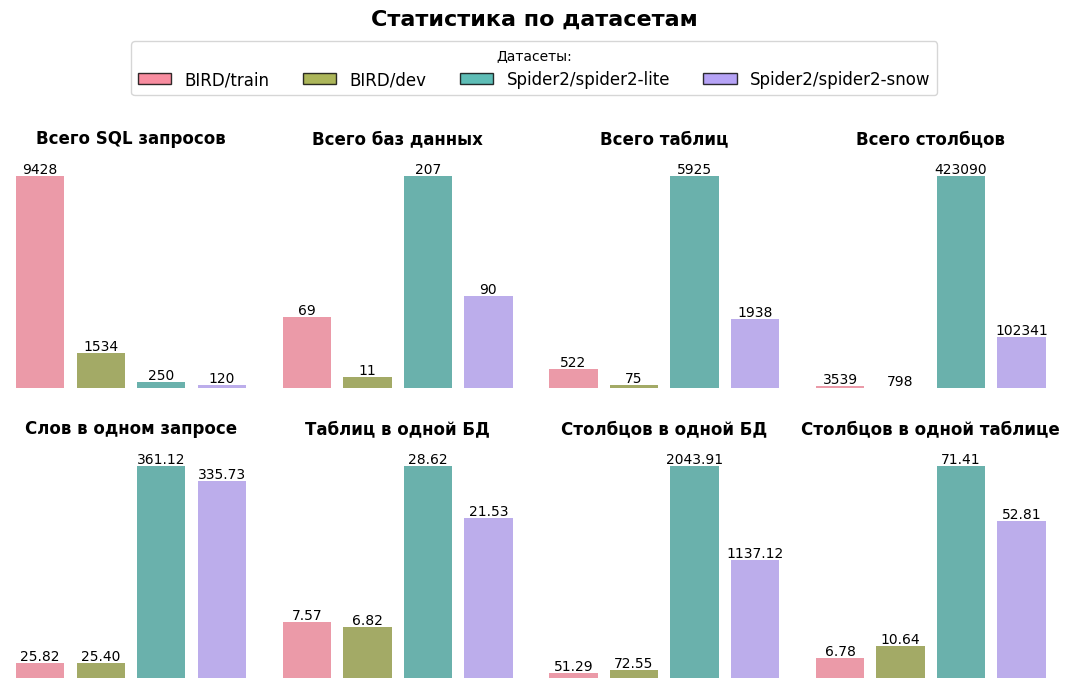

In [ ]:
df_melted = db_stat[[
        'dataset',
        'total_queries', 
        'total_dbs', 
        'total_tables', 
        'total_columns',
        "mean_query_words", 
        'mean_db_tb', 
        'mean_db_cl', 
        'mean_tb_cl']].rename(
    columns={
        'total_queries': 'Всего SQL запросов', 
        'total_dbs': 'Всего баз данных', 
        'total_tables': 'Всего таблиц', 
        'total_columns': 'Всего столбцов', 
        'mean_db_tb': 'Таблиц в одной БД', 
        'mean_db_cl': "Столбцов в одной БД", 
        'mean_tb_cl': "Столбцов в одной таблице", 
        "mean_query_words": "Слов в одном запросе"
    }).melt(
        id_vars='dataset', 
        var_name='stat', 
        value_name='vals'
    )

g = sns.FacetGrid(df_melted, 
                  col='stat', 
                  col_wrap=(len(db_stat.columns) - 1) // 2,
                  height=3, 
                  aspect=0.9,
                  sharey=False)

g.map_dataframe(sns.barplot, 
                x='dataset', 
                y='vals',
                hue='dataset',  
                palette='husl',
                dodge=False,  
                errorbar=None, alpha=0.8)

g.set_titles('{col_name}', size=12, fontweight=700, y=1.06)
g.set_axis_labels('', '')

for i, ax in enumerate(g.axes.flat):
    ax.set_xticklabels([])
    if 'Всего' in str(ax.title):
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=0, fontsize=10)
    else:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=0, fontsize=10)

    ax.axis("off")


colors = sns.color_palette('husl', len(db_stat['dataset']))

legend_elements = [Patch(facecolor=colors[i], 
                         edgecolor='black',
                         label=city, alpha=0.8) 
                   for i, city in enumerate(db_stat['dataset'])]

g.fig.legend(handles=legend_elements,
             title='Датасеты:',
             loc='upper center',
             bbox_to_anchor=(0.5, 1.1),
             ncol=len(db_stat['dataset']),
             fontsize=12,
             frameon=True,
             fancybox=True)

plt.suptitle('Статистика по датасетам', y=1.14, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.3)

In [185]:
syntax_stat

,dataset,syntax,freq
0,BIRD/train,SELECT,10284
1,BIRD/train,WHERE,8550
2,BIRD/train,JOIN,9593
3,BIRD/train,LIMIT,1829
4,BIRD/train,ORDER BY,1750
5,BIRD/train,DESC,1642
6,BIRD/train,GROUP BY,1026
7,BIRD/train,BETWEEN,313
8,BIRD/train,HAVING,139
9,BIRD/train,WITH,1


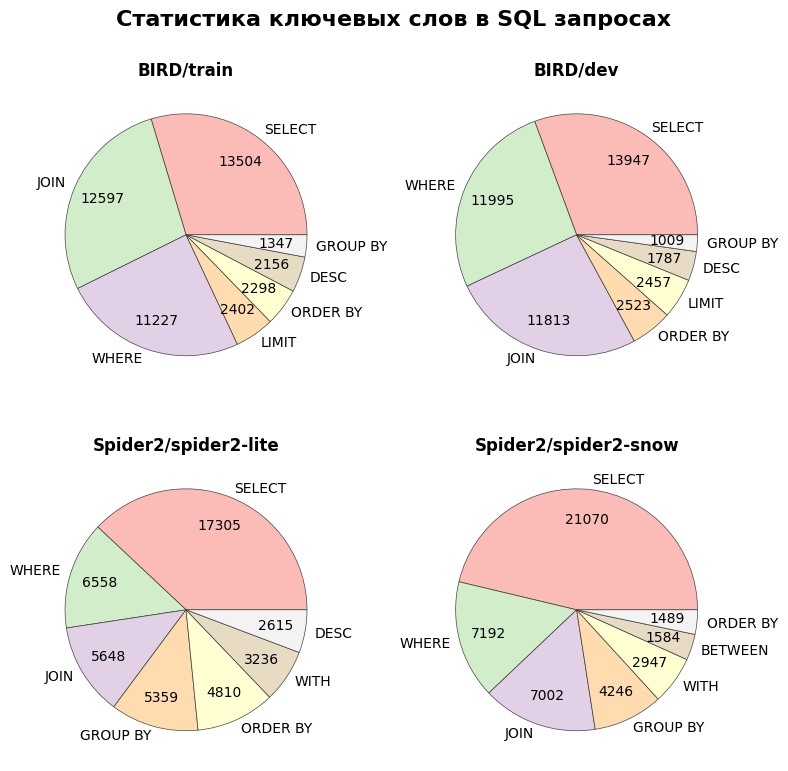

In [214]:
uds = syntax_stat['dataset'].unique()
fig, ax = plt.subplots(len(uds) // 2, 2)
ax = ax.flatten()
fig.set_figwidth(len(uds) * 2)
fig.set_figheight(len(uds) * 2)
for i, ds in enumerate(uds):
    subdata = syntax_stat.loc[syntax_stat['dataset'] == ds].copy().sort_values('freq', ascending=False)
    subdata = subdata[subdata['freq'] > subdata['freq'].quantile(0.25)]
    ax[i].pie(subdata['freq'], # explode=[0.015 for _ in range(len(subdata))],
              labels=subdata['syntax'], 
              colors=plt.cm.Pastel1_r(np.linspace(0.1, 0.9, len(subdata))[::-1]),
              autopct=lambda p: f"{p/100*syntax_stat['freq'].sum():.0f}", 
              pctdistance=0.75, startangle=0, labeldistance=1.08,
              wedgeprops={'edgecolor': '#333333', 'linewidth': 0.5, 'linestyle': '-', 'alpha': 0.9})
    ax[i].set_title(ds, fontweight=600, fontsize=12)
    # plt.pie()

plt.suptitle("Статистика ключевых слов в SQL запросах", fontweight=700, fontsize=16)
plt.tight_layout();

In [186]:
dialects_stat

,dialect,total_queries,total_dbs,total_tables,total_columns,mean_db_tb,mean_db_cl,mean_tb_cl
0,sqlite,135,30,432,3011,14.400,100.367,6.970
1,bigquery,205,154,5497,414108,35.695,2689.013,75.333
2,snowflake,207,121,2326,115269,19.223,952.636,49.557


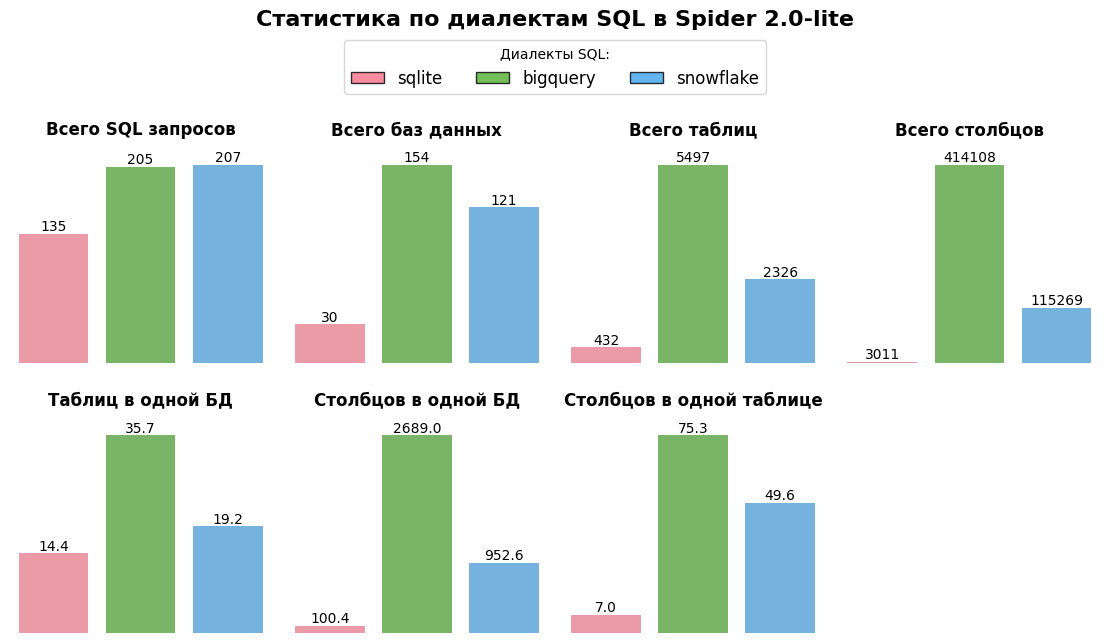

In [230]:
df_melted = dialects_stat[[
        'dialect',
        'total_queries', 
        'total_dbs', 
        'total_tables', 
        'total_columns', 
        'mean_db_tb', 
        'mean_db_cl', 
        'mean_tb_cl']].rename(
    columns={
        'total_queries': 'Всего SQL запросов', 
        'total_dbs': 'Всего баз данных', 
        'total_tables': 'Всего таблиц', 
        'total_columns': 'Всего столбцов', 
        'mean_db_tb': 'Таблиц в одной БД', 
        'mean_db_cl': "Столбцов в одной БД", 
        'mean_tb_cl': "Столбцов в одной таблице", 
    }).melt(
        id_vars='dialect', 
        var_name='stat', 
        value_name='vals'
    )

g = sns.FacetGrid(df_melted, 
                  col='stat', 
                  col_wrap=(len(dialects_allowed_stat.columns) - 1) // 2,
                  height=2.8, 
                  aspect=1.0,
                  sharey=False)

g.map_dataframe(sns.barplot, 
                x='dialect', 
                y='vals',
                hue='dialect',  
                palette='husl',
                dodge=False,  
                errorbar=None, alpha=0.8)

g.set_titles('{col_name}', size=12, fontweight=700, y=1.06)
g.set_axis_labels('', '')

for i, ax in enumerate(g.axes.flat):
    ax.set_xticklabels([])
    if 'Всего' in str(ax.title):
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=0, fontsize=10)
    else:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=0, fontsize=10)

    ax.axis("off")


colors = sns.color_palette('husl', len(dialects_stat['dialect']))

legend_elements = [Patch(facecolor=colors[i], 
                         edgecolor='black',
                         label=city, alpha=0.8) 
                   for i, city in enumerate(dialects_stat['dialect'])]

g.fig.legend(handles=legend_elements,
             title='Диалекты SQL:',
             loc='upper center',
             bbox_to_anchor=(0.5, 1.1),
             ncol=len(dialects_stat['dialect']),
             fontsize=12,
             frameon=True,
             fancybox=True)

plt.suptitle('Статистика по диалектам SQL в Spider 2.0-lite', y=1.14, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.3)

In [187]:
dialects_allowed_stat

,dialect,total_queries,total_dbs,total_tables,total_columns,mean_db_tb,mean_db_cl,mean_tb_cl,mean_query_words
0,sqlite,24,14,202,1688,14.429,120.571,8.356,411.333333
1,bigquery,142,119,4095,322427,34.412,2709.471,78.737,300.373239
2,snowflake,84,74,1628,98975,22.000,1337.500,60.795,446.500000


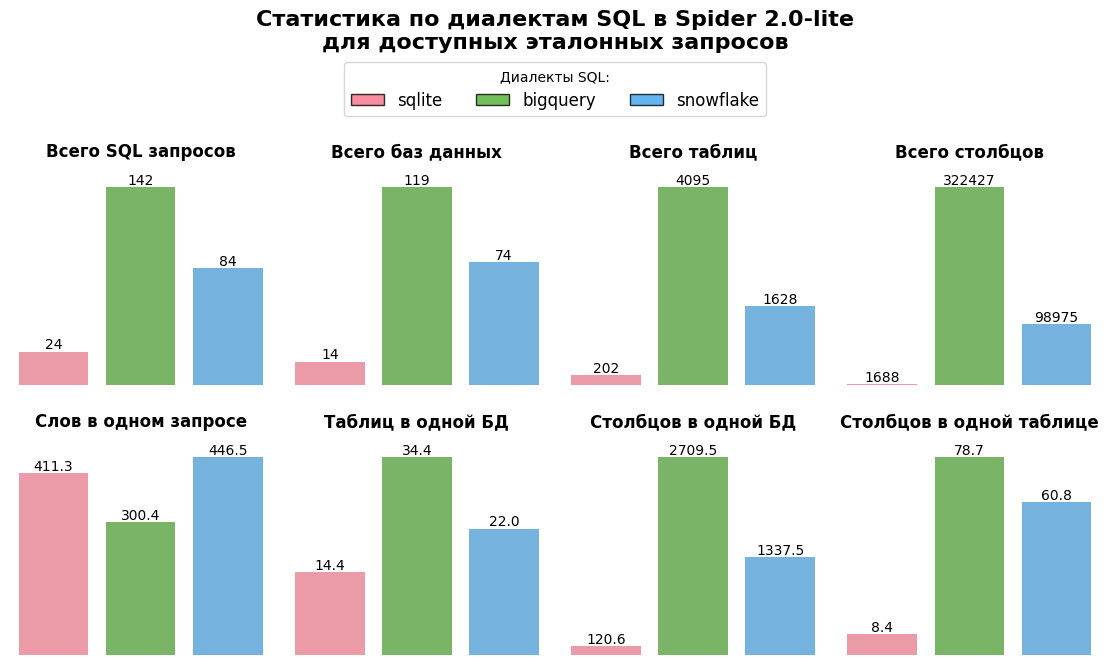

In [231]:
df_melted = dialects_allowed_stat[[
        'dialect',
        'total_queries', 
        'total_dbs', 
        'total_tables', 
        'total_columns',
        "mean_query_words", 
        'mean_db_tb', 
        'mean_db_cl', 
        'mean_tb_cl']].rename(
    columns={
        'total_queries': 'Всего SQL запросов', 
        'total_dbs': 'Всего баз данных', 
        'total_tables': 'Всего таблиц', 
        'total_columns': 'Всего столбцов', 
        'mean_db_tb': 'Таблиц в одной БД', 
        'mean_db_cl': "Столбцов в одной БД", 
        'mean_tb_cl': "Столбцов в одной таблице", 
        'mean_query_words': "Слов в одном запросе"
    }).melt(
        id_vars='dialect', 
        var_name='stat', 
        value_name='vals'
    )

g = sns.FacetGrid(df_melted, 
                  col='stat', 
                  col_wrap=(len(dialects_allowed_stat.columns) - 1) // 2,
                  height=2.8, 
                  aspect=1.0,
                  sharey=False)

g.map_dataframe(sns.barplot, 
                x='dialect', 
                y='vals',
                hue='dialect',  
                palette='husl',
                dodge=False,  
                errorbar=None, alpha=0.8)

g.set_titles('{col_name}', size=12, fontweight=700, y=1.06)
g.set_axis_labels('', '')

for i, ax in enumerate(g.axes.flat):
    ax.set_xticklabels([])
    if 'Всего' in str(ax.title):
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=0, fontsize=10)
    else:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=0, fontsize=10)

    ax.axis("off")


colors = sns.color_palette('husl', len(dialects_allowed_stat['dialect']))

legend_elements = [Patch(facecolor=colors[i], 
                         edgecolor='black',
                         label=city, alpha=0.8) 
                   for i, city in enumerate(dialects_allowed_stat['dialect'])]

g.fig.legend(handles=legend_elements,
             title='Диалекты SQL:',
             loc='upper center',
             bbox_to_anchor=(0.5, 1.1),
             ncol=len(dialects_allowed_stat['dialect']),
             fontsize=12,
             frameon=True,
             fancybox=True)

plt.suptitle('Статистика по диалектам SQL в Spider 2.0-lite\nдля доступных эталонных запросов', y=1.18, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.3)